In [31]:
import pandas as pd
import numpy as np
file_path = r"../reference_files/2025OzoneDataCalibrated/AllMDA8Voz.csv"  # Replace with your file path
vozdata = pd.read_csv(file_path, parse_dates=["date_time"])

vozdata = vozdata.melt(
    id_vars="date_time",
    var_name="location",
    value_name="MDA8"
)

vozdata.to_csv("../reference_files/2025OzoneDataCalibrated/MDA8LongVoz.csv")

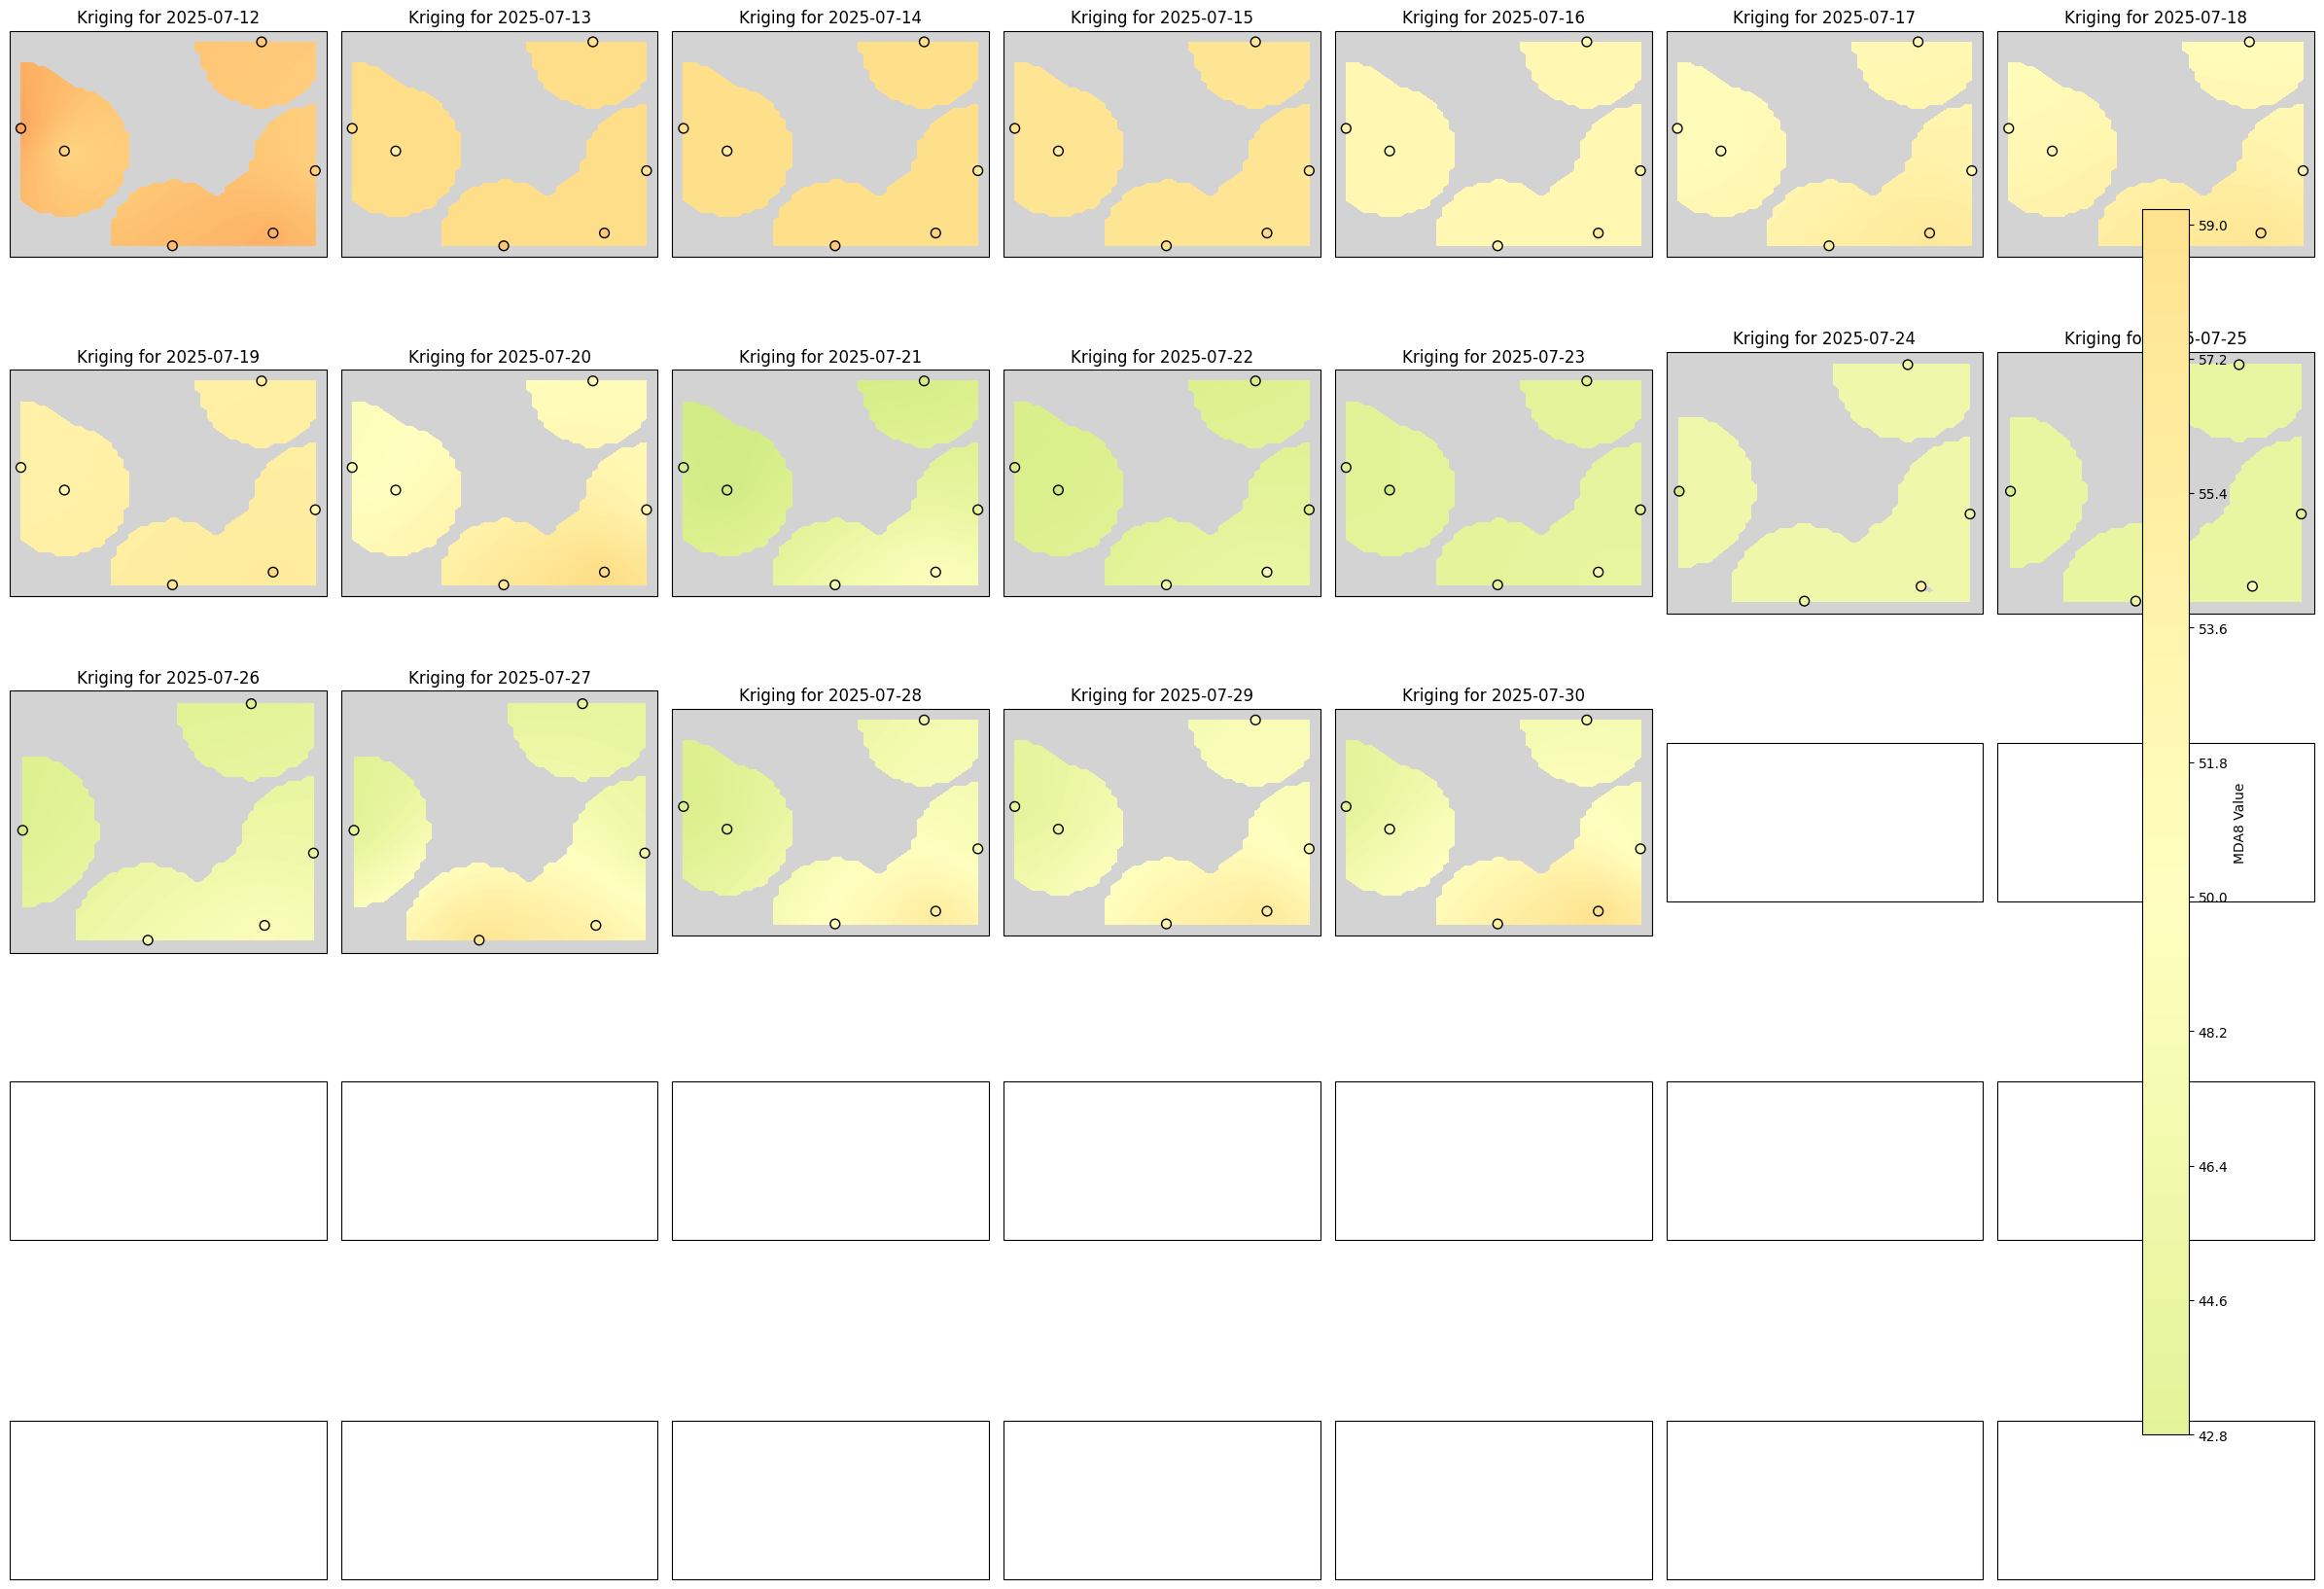

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree

coords_dfvoz = pd.read_csv(r"../reference_files/2025rawdata/deployment_locations.csv")
coords_dfref = pd.read_csv(r"../reference_files/FEMCoordinatesozone.csv")
coords_df = pd.concat([coords_dfref, coords_dfvoz])
# Create a dictionary: {name: (lat, lon)}
coords_dict = {row["name"]: (row["lat"], row["lon"]) for _, row in coords_df.iterrows()}
lat_dict = dict(zip(coords_df["name"], coords_df["lat"]))
lon_dict = dict(zip(coords_df["name"], coords_df["lon"]))

# Get unique days in July
days_in_july = pd.date_range(start='2025-07-12', end='2025-07-30', freq='D')

# Create a figure with subplots (5 rows, 7 columns for the 30 days of July)
fig, axs = plt.subplots(5, 7, figsize=(24, 18), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

# Define the radius of influence
radius_of_influence = 0.3  # Adjust as 

# Loop through each day in July and create a kriging plot for each
for i, day in enumerate(days_in_july):

    # --- Filter the vozdata for this day and drop NaN MDA8 values ---
    filtered = vozdata[vozdata["date_time"] == day].dropna(subset=["MDA8"])
    
    if filtered.empty:
        axs[i].set_title(f"{day.date()}: No Data")
        axs[i].axis("off")
        continue

    # --- Get the lat/lon for the filtered locations from coords_dict ---
    lats = [coords_dict[loc][0] for loc in filtered["location"]]
    lons = [coords_dict[loc][1] for loc in filtered["location"]]
    # --- Get ozone values ---
    values = filtered["MDA8"].values

    # --- Mask any remaining NaNs (just in case) ---
    mask = ~np.isnan(values)
    values_clean = values[mask]
    lats_clean = np.array(lats)[mask]
    lons_clean = np.array(lons)[mask]

    # Prepare grid for kriging
    grid_lon = np.linspace(lons_clean.min(), lons_clean.max(), 50)
    grid_lat = np.linspace(lats_clean.min(), lats_clean.max(), 50)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    # --- Ordinary Kriging ---
    OK = OrdinaryKriging(
        lons_clean,
        lats_clean,
        values_clean,
        variogram_model='linear',
        verbose=False,
        enable_plotting=False
    )

    # --- Build grid, execute kriging, plot contours and scatter points ---
    # (same as your old loop)


    z, ss = OK.execute("grid", grid_lon[0], grid_lat[:, 0])

    # Compute distance mask
    grid_points = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    data_points = np.vstack([lons_clean, lats_clean]).T
    tree = cKDTree(data_points)
    distances, _ = tree.query(grid_points)
    distance_mask = distances.reshape(grid_lon.shape)

    z = np.ma.masked_where(distance_mask > radius_of_influence, z)

    ax = axs[i]
    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    contour = ax.contourf(
        grid_lon, grid_lat, z,
        levels=100,
        cmap="RdYlGn_r",
        vmin=0, vmax=100,
        transform=ccrs.PlateCarree()
    )

    ax.scatter(
        lons_clean, lats_clean,
        c=values_clean,
        s=50, edgecolor="k",
        cmap="RdYlGn_r",
        vmin=0, vmax=100,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([
        lons_clean.min() - 0.05,
        lons_clean.max() + 0.05,
        lats_clean.min() - 0.05,
        lats_clean.max() + 0.05,
    ])

    ax.set_title(f"Kriging for {day.date()}")


# Adjust layout and add a colorbar for the entire figure
fig.tight_layout()
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Colorbar position [left, bottom, width, height]
fig.colorbar(contour, cax=cbar_ax, label='MDA8 Value')


In [33]:
file_path = r"../reference_files/2025OzoneDataCalibrated/AllMDA8Ref.csv"  # Replace with your file path
refdata = pd.read_csv(file_path, parse_dates=["date_time"])

refdata = refdata.melt(
    id_vars="date_time",
    var_name="location",
    value_name="MDA8"
)

refdata.to_csv("../reference_files/2025OzoneDataCalibrated/MDA8LongRef.csv")


      date_time     location       MDA8       date
0    2025-06-01       Clovis  52.912500 2025-06-01
1    2025-06-02       Clovis  61.887500 2025-06-02
2    2025-06-03       Clovis  61.237500 2025-06-03
3    2025-06-04       Clovis  60.428571 2025-06-04
4    2025-06-05       Clovis  60.162500 2025-06-05
...         ...          ...        ...        ...
2062 2025-11-02  Bakersfield  59.675000 2025-11-02
2063 2025-11-03  Bakersfield  56.362500 2025-11-03
2064 2025-11-04  Bakersfield  48.425000 2025-11-04
2065 2025-11-05  Bakersfield  40.162500 2025-11-05
2066 2025-11-06  Bakersfield  30.862500 2025-11-06

[2050 rows x 4 columns]


C:\Users\tlc72\AppData\Local\Temp\ipykernel_112124\3396724347.py:205: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ] + ax.get_legend_handles_labels()[0],    # include existing scatter legend


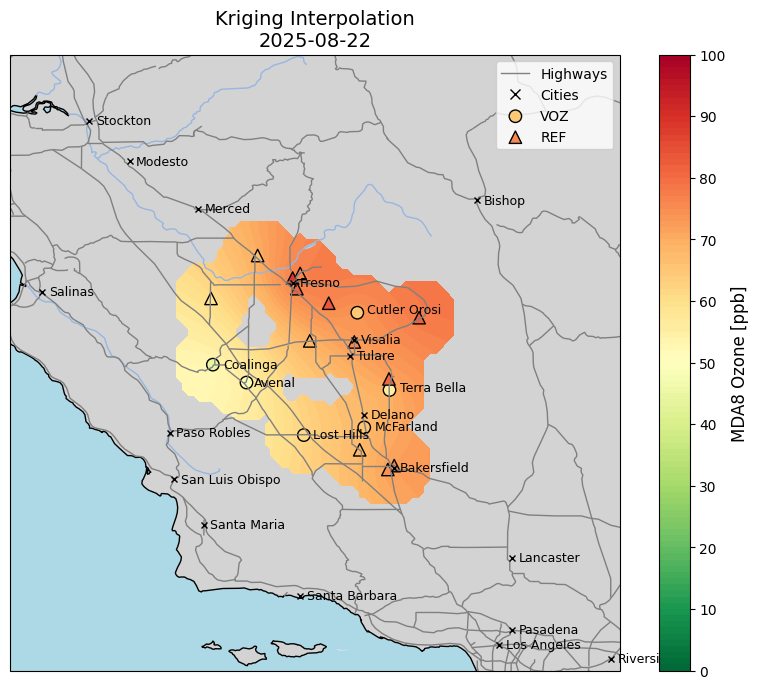

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree
import cartopy.io.shapereader as shpreader
import matplotlib.lines as mlines


# Pick a single day to plot:
day_to_plot = pd.Timestamp("2025-08-22")

# Ensure consistent datetime
vozdata['date'] = pd.to_datetime(vozdata['date_time'])
refdata['date'] = pd.to_datetime(refdata['date_time'])

# Drop missing values
vozdata = vozdata.dropna(subset=["MDA8"])
refdata = refdata.dropna(subset=["MDA8"])

print(refdata)

radius_of_influence = 0.3


# -------------------------------------------------
# Helper: extract lat/lon/value from coords_dict
# -------------------------------------------------
def get_coords(df):
    df = df[df["location"].isin(coords_dict.keys())]

    lats = df["location"].apply(lambda x: coords_dict[x][0]).values
    lons = df["location"].apply(lambda x: coords_dict[x][1]).values
    vals = df["MDA8"].values

    mask = ~np.isnan(vals)
    return lats[mask], lons[mask], vals[mask]


# -------------------------------------------------
# Filter 1-day data
# -------------------------------------------------
voz_day = vozdata[vozdata["date"] == day_to_plot]
ref_day = refdata[refdata["date"] == day_to_plot]

# Get coordinate arrays
lats_v, lons_v, vals_v = get_coords(voz_day)
lats_r, lons_r, vals_r = get_coords(ref_day)

# Combine
lats = np.hstack([lats_v, lats_r])
lons = np.hstack([lons_v, lons_r])
vals = np.hstack([vals_v, vals_r])

if len(vals) == 0:
    print("No data available for", day_to_plot.date())
    exit()


# -------------------------------------------------
# Build grid (same logic as before)
# -------------------------------------------------
grid_lon = np.linspace(lons.min() - radius_of_influence, lons.max() + radius_of_influence, 50)
grid_lat = np.linspace(lats.min() - radius_of_influence, lats.max() + radius_of_influence, 50)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Kriging
OK = OrdinaryKriging(
    lons, lats, vals,
    variogram_model="linear",
    verbose=False,
    enable_plotting=False
)

z, ss = OK.execute("grid", grid_lon[0], grid_lat[:, 0])

# Distance mask
grid_points = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
data_points = np.vstack([lons, lats]).T
tree = cKDTree(data_points)
distances, _ = tree.query(grid_points)
distance_mask = distances.reshape(grid_lon.shape)

z = np.ma.masked_where(distance_mask > radius_of_influence, z)

# Check valid variation
zz = z.compressed()
if len(zz) == 0 or zz.min() == zz.max():
    print("Not enough variation to contour.")
    exit()


# -------------------------------------------------
# Plot single map
# -------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')
ax.add_feature(cfeature.RIVERS)   # ← rivers added back

# Fixed contour levels
levels = np.linspace(0, 100, 101)

contour = ax.contourf(
    grid_lon, grid_lat, z,
    levels=levels,
    cmap="RdYlGn_r",
    vmin=0, vmax=100,       # ← match level range
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(contour, ax=ax)
cbar.set_ticks(np.arange(0, 101, 10))
cbar.set_label("MDA8 Ozone [ppb]", fontsize=12)
# Scatter points
if len(vals_v) > 0:
    ax.scatter(
        lons_v, lats_v, c=vals_v,
        s=80, edgecolor='k', cmap="RdYlGn_r",
        vmin=0, vmax=100, marker='o',
        transform=ccrs.PlateCarree(),
        label="VOZ"
    )

if len(vals_r) > 0:
    ax.scatter(
        lons_r, lats_r, c=vals_r,
        s=80, edgecolor='k', cmap="RdYlGn_r",
        vmin=0, vmax=100, marker='^',
        transform=ccrs.PlateCarree(),
        label="REF"
    )

# -------------------------------------------------
# ZOOMED-OUT MAP EXTENT
# -------------------------------------------------
zoom_out_deg = 1.5   # increase for more zoom out

ax.set_extent([
    lons.min() - zoom_out_deg,
    lons.max() + zoom_out_deg,
    lats.min() - zoom_out_deg,
    lats.max() + zoom_out_deg
], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.NaturalEarthFeature('cultural', 'roads', '10m', 
                                                edgecolor='gray', facecolor='none', linewidth=1), label='Highways')

shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='populated_places')
reader = shpreader.Reader(shpfilename)

for city in reader.records():
    city_name = city.attributes['NAME']
    city_lon, city_lat = city.geometry.x, city.geometry.y

    # Filter cities to plot within the map extent (optional)
    if (lons.min() - 1.5 <= city_lon <= lons.max() + 1.5 and
        lats.min() - 1.5 <= city_lat <= lats.max() + 1.5):

        # Plot the city point
        ax.plot(city_lon, city_lat, 'kx', markersize=5, transform=ccrs.PlateCarree())

        # Annotate the city name near the point
        ax.text(city_lon + 0.05, city_lat - 0.025, city_name, fontsize=9, transform=ccrs.PlateCarree())

custom_cities = {
    "Coalinga":    (36.13999659771615, -120.35938694925237),
    "Avenal": (36.004190729937605, -120.13038009344021),
    "McFarland":   (35.67865733239519, -119.22690100812619),
    "Lost Hills": (35.61722852439872, -119.69308777332819),
    "Cutler Orosi": (36.54806396891425, -119.29109666003598),
    "Terra Bella": (35.962716703182274, -119.04405260202688)
}

for name, (lat, lon) in custom_cities.items():

    # Add city name
    ax.text(
        lon + 0.07, lat - 0.025,   # small offset so text is readable
        name,
        fontsize=9,
        color='black',
        transform=ccrs.PlateCarree(),
        zorder=21,
    )

ax.set_title(f"Kriging Interpolation\n{day_to_plot.date()}", fontsize=14)
# plt.colorbar(contour, ax=ax, label="MDA8 Value")

# Proxy artists
highway_proxy = mlines.Line2D([], [], color='gray', linewidth=1, label='Highways')
city_proxy = mlines.Line2D([], [], color='black', marker='x', linestyle='None',
                           markersize=7, label='Cities')
# Add them to the legend
plt.legend(handles=[
    highway_proxy, city_proxy
] + ax.get_legend_handles_labels()[0],    # include existing scatter legend
           loc='upper right')
plt.savefig(rf"../../PlotsForRubenNov25/KrigingMapAug28.jpg", format='jpg', dpi=300)
plt.show()
